In [2]:
import os
import re
import joblib  

import numpy as np
from numpy import dot
from numpy.linalg import norm
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

import konlpy
from konlpy.tag import Okt
from nltk.corpus import abc


import gensim
from gensim.models import KeyedVectors
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

import torch
import torch.nn.functional as F

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
import matplotlib as mpl
import os
import shutil

# Matplotlib 캐시 디렉토리 경로 확인 및 삭제
cache_dir = mpl.get_cachedir()
print(f"현재 Matplotlib 캐시 경로: {cache_dir}")

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("기존 폰트 캐시를 성공적으로 삭제했습니다!")
else:
    print("삭제할 캐시가 없습니다.")

현재 Matplotlib 캐시 경로: /home/ysoh1113/.cache/matplotlib
기존 폰트 캐시를 성공적으로 삭제했습니다!


In [4]:
def cos_sim(i, j):
    return dot(i, j.T)/(norm(i)*norm(j))

def calculate_s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B #, c_a, c_b

def weat_score(X, Y, A, B):

    s_X = calculate_s(X, A, B)
    s_Y = calculate_s(Y, A, B)

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    return  (mean_X-mean_Y)/std_dev

In [ ]:
base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'word_embedding', 'data')

In [ ]:
okt = Okt()

file_path = os.path.join(base_path, 'synopsis.txt')
output_path = os.path.join(base_path, 'output', 'synopsis_nouns_okt.txt')
print("Okt를 이용하여 시놉시스 명사 추출을 시작합니다...")
nouns_sentences = []

with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    
    for line in tqdm(lines, desc="Processing Lines"):
        line = line.strip()
        if not line:
            continue
            
        # okt.nouns()를 사용하여 명사 리스트 추출
        # 단, 한 글자짜리 명사(예: '그', '이', '것')를 필터링하고 싶다면 아래 주석을 해제하세요.
        nouns = okt.nouns(line)
        # nouns = [word for word in nouns if len(word) > 1] 
        
        if nouns:
            nouns_sentences.append(" ".join(nouns))

with open(output_path, 'w', encoding='utf-8') as f_out:
    for sentence in nouns_sentences:
        f_out.write(sentence + "\n")

print(f"\n명사 추출 완료! 저장된 위치: {output_path}")

Okt를 이용하여 시놉시스 명사 추출을 시작합니다...


Processing Lines: 100%|██████████| 71156/71156 [03:06<00:00, 381.37it/s]



명사 추출 완료! 저장된 위치: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex04/../../work/word_embedding/data/output/synopsis_nouns_okt.txt


In [ ]:
file_path = os.path.join(base_path, 'synopsis')
output_path = os.path.join(base_path, 'nouns')
file_names = os.listdir(file_path)

okt = Okt()

for fname in file_names:
    nouns_sentences = []
    target_file_path = os.path.join(file_path, fname)
    output_file_path = os.path.join(output_path, f"nouns_okt_{fname}")

    with open(target_file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
        for line in tqdm(lines, desc="Processing Lines"):
            line = line.strip()
            if not line:
                continue
                
            # okt.nouns()를 사용하여 명사 리스트 추출
            # 단, 한 글자짜리 명사(예: '그', '이', '것')를 필터링하고 싶다면 아래 주석을 해제하세요.
            nouns = okt.nouns(line)
            nouns = [word for word in nouns if len(word) > 1] 
            
            if nouns:
                nouns_sentences.append(" ".join(nouns))
    

    with open(output_file_path, 'w', encoding='utf-8') as f_out:
        for sentence in nouns_sentences:
            f_out.write(sentence + "\n")

    print(f"\n명사 추출 완료! 저장된 위치: {output_file_path}")


Processing Lines: 100%|██████████| 239/239 [00:00<00:00, 480.22it/s]



명사 추출 완료! 저장된 위치: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex04/../../work/word_embedding/data/synopsis/nouns/nouns_okt_synopsis_historical.txt


Processing Lines: 100%|██████████| 71156/71156 [03:53<00:00, 304.81it/s]



명사 추출 완료! 저장된 위치: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex04/../../work/word_embedding/data/synopsis/nouns/nouns_okt_synopsis.txt


Processing Lines: 100%|██████████| 3687/3687 [00:09<00:00, 397.10it/s]


...

Processing Lines: 100%|██████████| 48/48 [00:00<00:00, 246.77it/s]


명사 추출 완료! 저장된 위치: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex04/../../work/word_embedding/data/synopsis/nouns/nouns_okt_synopsis_western.txt



Processing Lines: 100%|██████████| 48116/48116 [02:44<00:00, 292.51it/s]


명사 추출 완료! 저장된 위치: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex04/../../work/word_embedding/data/synopsis/nouns/nouns_okt_synopsis_gen.txt


IsADirectoryError: [Errno 21] Is a directory: '/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex04/../../work/word_embedding/data/synopsis/nouns'

In [6]:
model_path = os.path.join(base_path, 'models', 'synopsis_word2vec.model')
input_path = file_path

print("1. 명사 추출 파일 로드 및 코퍼스(Corpus) 구성 중...")

# 2. 데이터 로드 및 전처리
sentences = []
with open(input_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # 공백으로 쪼개어 단어 리스트(토큰 리스트) 생성
        tokens = line.split()
        sentences.append(tokens)

print(f"로드 완료! 총 {len(sentences)}개의 문장 코퍼스가 준비되었습니다.")

# 3. Word2Vec 모델 선언 및 학습 (하이퍼파라미터 설정)
print("\n2. Word2Vec 모델 학습 시작...")
model = Word2Vec(
    sentences=sentences,
    vector_size=100,    # 임베딩 벡터의 차원 수 (WEAT 실습용으로 100~300 적당)
    window=5,           # 컨텍스트 윈도우 크기 (앞뒤 5단어 탐색)
    min_count=5,        # 말뭉치 내 최소 등장 빈도 (5회 미만 단어는 제외)
    workers=4,          # 학습에 사용할 CPU 코어 수
    sg=0                # 0: CBOW (주변으로 중심 예측), 1: Skip-gram (중심으로 주변 예측)
)

# 4. 모델 저장
print("\n3. 학습 완료된 임베딩 모델 저장 중...")
model.save(model_path)
print(f"모델 저장 완료! 파일 위치: {model_path}")

# --- 여기서부터는 제대로 학습되었는지 검증하는 테스트 코드입니다 ---
print("\n" + "="*40)
print("🎯 학습된 임베딩 벡터 품질 테스트")
print("="*40)

# 테스트 단어 정의
test_word = '라디오'

if test_word in model.wv:
    print(f"단어 '{test_word}'와 가장 유사한 단어 Top 5:")
    # .wv.most_similar()를 사용하여 코사인 유사도가 가장 높은 단어를 뽑아냅니다.
    similar_words = model.wv.most_similar(test_word, topn=5)
    for word, similarity in similar_words:
        print(f" - {word}: {similarity:.4f}")
else:
    print(f"단어 '{test_word}'가 min_count 기준에 미달하여 사전(Vocabulary)에 존재하지 않습니다.")

1. 명사 추출 파일 로드 및 코퍼스(Corpus) 구성 중...
로드 완료! 총 71156개의 문장 코퍼스가 준비되었습니다.

2. Word2Vec 모델 학습 시작...

3. 학습 완료된 임베딩 모델 저장 중...
모델 저장 완료! 파일 위치: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/Exploration/Ex04/../../work/word_embedding/data/models/synopsis_word2vec.model

🎯 학습된 임베딩 벡터 품질 테스트
단어 '라디오'와 가장 유사한 단어 Top 5:
 - 무명: 0.9891
 - 청각장애인: 0.9847
 - 미술: 0.9842
 - 최고급: 0.9840
 - 작곡가인: 0.9836


In [ ]:
tfidf_model_path = os.path.join(base_path, 'models', 'tfidf_vectorizer.pkl')
matrix_path = os.path.join(base_path, 'models', 'tfidf_matrix.pkl')
input_path = os.path.join(base_path, 'synopsis', 'nouns')


print("1. 시놉시스 명사 파일 로드 중...")

# 2. 데이터 로드 (TfidfVectorizer는 공백으로 구분된 문자열 리스트를 입력으로 받습니다)
documents = []
with open(input_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            documents.append(line)

print(f"로드 완료! 총 {len(documents)}개의 영화 시놉시스 문서가 준비되었습니다.")

# 3. TF-IDF 모델(Vectorizer) 생성 및 학습
print("\n2. TF-IDF 변환기 학습 및 행렬 생성 시작...")
# 하이퍼파라미터 설정
vectorizer = TfidfVectorizer(
    min_df=5,          # Word2Vec의 min_count와 동일: 최소 5개 이상의 문서에 등장한 단어만 유효화
    max_df=0.95,       # 너무 자주 등장하는 단어(예: 영화, 스토리 등)는 패널티를 주어 제외 (95% 이상 문서 등장시 탈락)
    max_features=5000  # 추출할 핵심 단어 사전의 최대 개수 제한 (차원 제어용)
)

# 학습(fit)과 행렬 변환(transform)을 동시에 수행
# tfidf_matrix의 셰이프는 (총 문서 개수, max_features)가 됩니다.
tfidf_matrix = vectorizer.fit_transform(documents)

print(f"학습 완료! 생성된 TF-IDF 행렬 크기: {tfidf_matrix.shape}")

# 4. 추후 재사용을 위해 모델과 변환된 행렬 저장
print("\n3. 학습된 TF-IDF 모델 및 행렬 저장 중...")
joblib.dump(vectorizer, tfidf_model_path)
joblib.dump(tfidf_matrix, matrix_path)
print("저장 완료!")

# --- 여기서부터는 특정 문서에서 어떤 단어가 중요한지 확인하는 검증 코드입니다 ---
print("\n" + "="*40)
print("🎯 TF-IDF 벡터화 결과 검증 (첫 번째 시놉시스 분석)")
print("="*40)

# 첫 번째 영화 시놉시스의 TF-IDF 벡터 추출
first_doc_vector = tfidf_matrix[0]

# 단어 사전 및 해당 단어의 인덱스 매핑 정보 추출
feature_names = vectorizer.get_feature_names_out()

# 스파스 행렬(Sparse Matrix) 구조에서 값이 채워진 인덱스와 TF-IDF 점수 추출
coo = first_doc_vector.tocoo()
word_scores = [(feature_names[col], score) for col, score in zip(coo.col, coo.data)]

# 점수가 높은 순으로 정렬
word_scores = sorted(word_scores, key=lambda x: x[1], reverse=True)

print(f"원본 명사 텍스트:\n > {documents[0]}")
print("\n해당 영화 시놉시스 내 TF-IDF 중요도 Top 5 단어:")
for word, score in word_scores[:5]:
    print(f" - {word}: {score:.4f}")

1. 시놉시스 명사 파일 로드 중...
로드 완료! 총 71156개의 영화 시놉시스 문서가 준비되었습니다.

2. TF-IDF 변환기 학습 및 행렬 생성 시작...
학습 완료! 생성된 TF-IDF 행렬 크기: (71156, 5000)

3. 학습된 TF-IDF 모델 및 행렬 저장 중...
저장 완료!

🎯 TF-IDF 벡터화 결과 검증 (첫 번째 시놉시스 분석)
원본 명사 텍스트:
 > 사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와

해당 영화 시놉시스 내 TF-IDF 중요도 Top 5 단어:
 - 치매에: 0.6500
 - 할머니: 0.5587
 - 걸린: 0.5151


In [8]:
# 1. WEAT 분석을 위한 개념별 단어 셋 정의 (영화 시놉시스 맞춤형)
# Target X: 예술/독립영화 관련 단어
target_X_words = ['예술', '독립', '다큐멘터리', '페스티벌', '영화제', '평론가', '작품', '메시지', '인생', '소외']
# Target Y: 상업/일반영화 관련 단어
target_Y_words = ['상업', '흥행', '블록버스터', '제작비', '관객', '개봉', '극장', '스타', '엔터테인먼트', '히트']

# Attribute A: 드라마/멜로/가족 장르 관련 단어
attribute_A_words = ['사랑', '이별', '가족', '어머니', '아버지', '눈물', '갈등', '행복', '추억', '연인']
# Attribute B: SF/액션/범죄 장르 관련 단어
attribute_B_words = ['우주', '미래', '로봇', '외계인', '과학', '범죄', '추적', '액션', '조직', '사건']

# 2. 단어 문자열 리스트를 임베딩 벡터 행렬로 변환하는 헬퍼 함수
def get_word_matrix(word_list, model):
    matrix = []
    for word in word_list:
        if word in model.wv:  # Word2Vec 사전에 단어가 존재하는지 확인 (OOV 방어)
            matrix.append(model.wv[word])
        else:
            # 학습 때 min_count 등으로 탈락한 단어는 제외합니다.
            print(f"⚠️ 단어 '{word}'는 사전에 없어 제외됩니다.")
            
    return np.array(matrix)

print("1. 단어 리스트를 Word2Vec 임베딩 벡터 행렬로 변환 중...")
# 앞서 학습하고 저장한 model 인스턴스가 활성화되어 있다고 가정합니다.
X = get_word_matrix(target_X_words, model)
Y = get_word_matrix(target_Y_words, model)
A = get_word_matrix(attribute_A_words, model)
B = get_word_matrix(attribute_B_words, model)

print(f"\n변환 완료 셰이프 (단어 수, 임베딩 차원):")
print(f" - X (예술): {X.shape}, Y (상업): {Y.shape}")
print(f" - A (드라마): {A.shape}, B (SF/액션): {B.shape}")

# 3. 작성해주신 WEAT 계산 함수 가동
print("\n2. WEAT 스코어 계산 시작...")
score = weat_score(X, Y, A, B)

print("\n" + "="*40)
print(f"🎯 최종 WEAT Score: {score:.4f}")
print("="*40)

# 4. 결과 해석 가이드 출력
if score > 0:
    print("💡 해석: 예술영화(X)는 드라마/가족(A) 속성과 가깝고,")
    print("        상업영화(Y)는 SF/액션(B) 속성과 더 긴밀하게 연합되어 있습니다.")
elif score < 0:
    print("💡 해석: 예술영화(X)는 SF/액션(B) 속성과 가깝고,")
    print("        상업영화(Y)는 드라마/가족(A) 속성과 더 긴밀하게 연합되어 있습니다.")
else:
    print("💡 해석: 임베딩 공간 내에서 장르적 편향성이 발견되지 않은 완벽한 중립 상태입니다.")

1. 단어 리스트를 Word2Vec 임베딩 벡터 행렬로 변환 중...

변환 완료 셰이프 (단어 수, 임베딩 차원):
 - X (예술): (10, 100), Y (상업): (10, 100)
 - A (드라마): (10, 100), B (SF/액션): (10, 100)

2. WEAT 스코어 계산 시작...

🎯 최종 WEAT Score: -0.1229
💡 해석: 예술영화(X)는 SF/액션(B) 속성과 가깝고,
        상업영화(Y)는 드라마/가족(A) 속성과 더 긴밀하게 연합되어 있습니다.


In [9]:

# 1. 주어진 장르 데이터셋 정보 정의
genre_txt = [
    'synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
    'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
    'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
    'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
    'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt'
]
genre_name = [
    'SF', '가족', '공연', '공포(호러)', '기타',
    '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬',
    '미스터리', '범죄', '사극', '서부극(웨스턴)',
    '성인물(에로)', '스릴러', '애니메이션', '액션',
    '어드벤처', '전쟁', '코미디', '판타지'
]

data_dir = base_path

# 2. 21개 장르별 파일을 읽어 '장르당 1개의 거대 문서'로 통합 코퍼스 생성
genre_documents = []
for txt_file in genre_txt:
    file_path = os.path.join(data_dir, txt_file)
    
    # 만약 기존 실습에서 명사 추출 본을 다른 이름으로 만들었다면 그에 맞게 파일명을 매핑하셔도 됩니다.
    # 여기서는 원본 파일 구조를 읽어 결합하는 구조로 작성했습니다.
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            # 한 장르 파일 안의 모든 명사 단어들을 하나의 공백 문자열로 결합
            genre_content = " ".join([line.strip() for line in lines if line.strip()])
            genre_documents.append(genre_content)
    else:
        # 안전장치: 파일이 없을 경우 빈 문자열 할당
        print(f"⚠️ 파일을 찾을 수 없습니다: {file_path}")
        genre_documents.append("")

print(f"1. 총 {len(genre_documents)}개의 장르 문서 통합 완료.")

# 3. 장르 레벨에서 TF-IDF Vectorizer 학습
# 전 장르에 다 나오는 단어를 잡기 위해 max_df를 장르 개수 비율로 제어합니다.
vectorizer = TfidfVectorizer(max_df=0.85, min_df=1) 
tfidf_matrix = vectorizer.fit_transform(genre_documents)
feature_names = vectorizer.get_feature_names_out()

# 4. 각 장르별로 TF-IDF 상위 100개 단어를 우선 추출 (1차 후보군)
genre_top_words = {}
top_n = 100

for idx, name in enumerate(genre_name):
    row = tfidf_matrix[idx].toarray()[0]
    # 점수가 높은 순으로 인덱스 정렬
    top_indices = np.argsort(row)[::-1][:top_n]
    
    # 해당 장르의 상위 단어와 점수 매핑 (점수가 0인 단어는 제외)
    words = [feature_names[i] for i in top_indices if row[i] > 0]
    genre_top_words[name] = words

# 5. 🔥 핵심 개선 알고리즘: 중복 단어 전면 제거 (차집합 및 교집합 제어)
print("\n2. 장르 간 중복 단어 스크리닝 및 필터링 시작...")

final_genre_words = {}
desired_final_count = 15  # WEAT 단어 셋으로 사용할 최종 정예 단어 수

for target_genre in genre_name:
    target_candidates = genre_top_words[target_genre]
    
    # 타 장르들의 모든 상위 단어들을 하나의 풀(Pool)로 결합
    other_genres_words_pool = set()
    for other_genre in genre_name:
        if other_genre != target_genre:
            other_genres_words_pool.update(genre_top_words[other_genre])
            
    # 순수 차집합 연산: 오직 '나의 장르' 상위권에만 존재하고, 타 장르 상위권에는 절대 없는 단어 필터링
    pure_words = [word for word in target_candidates if word not in other_genres_words_pool]
    
    # 만약 엄격한 필터링으로 단어가 너무 부족해지면, 상위권 점수 순서대로 복원
    if len(pure_words) < desired_final_count:
        shortage = desired_final_count - len(pure_words)
        # 중복이 있더라도 타 장르에서 출현 빈도가 낮았던 상위 단어로 보충
        overflow_words = [word for word in target_candidates if word not in pure_words]
        pure_words.extend(overflow_words[:shortage])
        
    # 최종 정예 개수만큼 슬라이싱
    final_genre_words[target_genre] = pure_words[:desired_final_count]

# 6. 결과 출력 (예시로 WEAT에 자주 쓰이는 4개 대표 장르 출력)
print("\n" + "="*50)
print("🎯 개선된 장르별 독점적 대표 단어 셋 구축 완료")
print("="*50)

sample_genres = ['SF', '멜로로맨스', '공포(호러)', '다큐멘터리']
for g in sample_genres:
    if g in final_genre_words:
        print(f" 장르 [{g}] 대표 단어 셋:")
        print(f" ➔ {final_genre_words[g]}\n")

1. 총 21개의 장르 문서 통합 완료.

2. 장르 간 중복 단어 스크리닝 및 필터링 시작...

🎯 개선된 장르별 독점적 대표 단어 셋 구축 완료
 장르 [SF] 대표 단어 셋:
 ➔ ['외계', '지구에', '우주', '지구', '미래', '미래의', 'dna', '박사는', '지구의', '지구로', '섹터', '토니', '인류', '인류는', '스타크']

 장르 [멜로로맨스] 대표 단어 셋:
 ➔ ['연애', '사랑은', '부부', '사랑이', '애인', '둘의', '친구의', '호감을', '즐기는', '자꾸만', '커플', '출장을', '하룻밤을', '밤을', '젊고']

 장르 [공포(호러)] 대표 단어 셋:
 ➔ ['공포', '섬뜩한', '공포의', '좀비', '악령의', '기괴한', '저주의', '로즈', '귀신이', '어두운', '악령을', '악령이', '불길한', '공포가', '캠핑을']

 장르 [다큐멘터리] 대표 단어 셋:
 ➔ ['dmz국제다큐영화제', '다큐멘터리', '국제다큐영화제', 'ebs', '인디다큐페스티발', '다큐멘터리는', 'dmz국제다큐멘터리', 'dmz국제다큐멘터리영화제', '우리가', '10회', '울주세계산악영화제', '서울국제건축영화제', '당시', '삶과', '감독이']



⚠️ 단어 '서울국제초단편영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '서울국제뉴미디어페스티벌'는 사전에 없어 제외됩니다.
⚠️ 단어 '유럽단편영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 'dmz국제다큐영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '국제다큐영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 'ebs'는 사전에 없어 제외됩니다.
⚠️ 단어 '인디다큐페스티발'는 사전에 없어 제외됩니다.
⚠️ 단어 'sicaf'는 사전에 없어 제외됩니다.
⚠️ 단어 '최강애니전'는 사전에 없어 제외됩니다.
⚠️ 단어 'dna'는 사전에 없어 제외됩니다.
⚠️ 단어 '씨제이'는 사전에 없어 제외됩니다.
⚠️ 단어 '크리쉬나'는 사전에 없어 제외됩니다.
⚠️ 단어 '닐라'는 사전에 없어 제외됩니다.
⚠️ 단어 '아스마르'는 사전에 없어 제외됩니다.
⚠️ 단어 '베일리'는 사전에 없어 제외됩니다.
⚠️ 단어 '썬더맨'는 사전에 없어 제외됩니다.
⚠️ 단어 '아주르와'는 사전에 없어 제외됩니다.
⚠️ 단어 '서울국제뉴미디어페스티벌'는 사전에 없어 제외됩니다.
⚠️ 단어 '국제지하철영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '유럽단편영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '부산독립영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 'dmz국제다큐영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '국제다큐영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 'ebs'는 사전에 없어 제외됩니다.
⚠️ 단어 '인디다큐페스티발'는 사전에 없어 제외됩니다.
⚠️ 단어 'dmz국제다큐멘터리'는 사전에 없어 제외됩니다.
⚠️ 단어 'dmz국제다큐멘터리영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '울주세계산악영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '서울국제건축영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '충무로뮤지컬영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '손나'는 사전에 없어 제외됩니다.
⚠️ 단어 '니웨'는 사전에 없어 제외됩니다.
⚠️ 단어 '모차르트'는 사전에 없어 제외

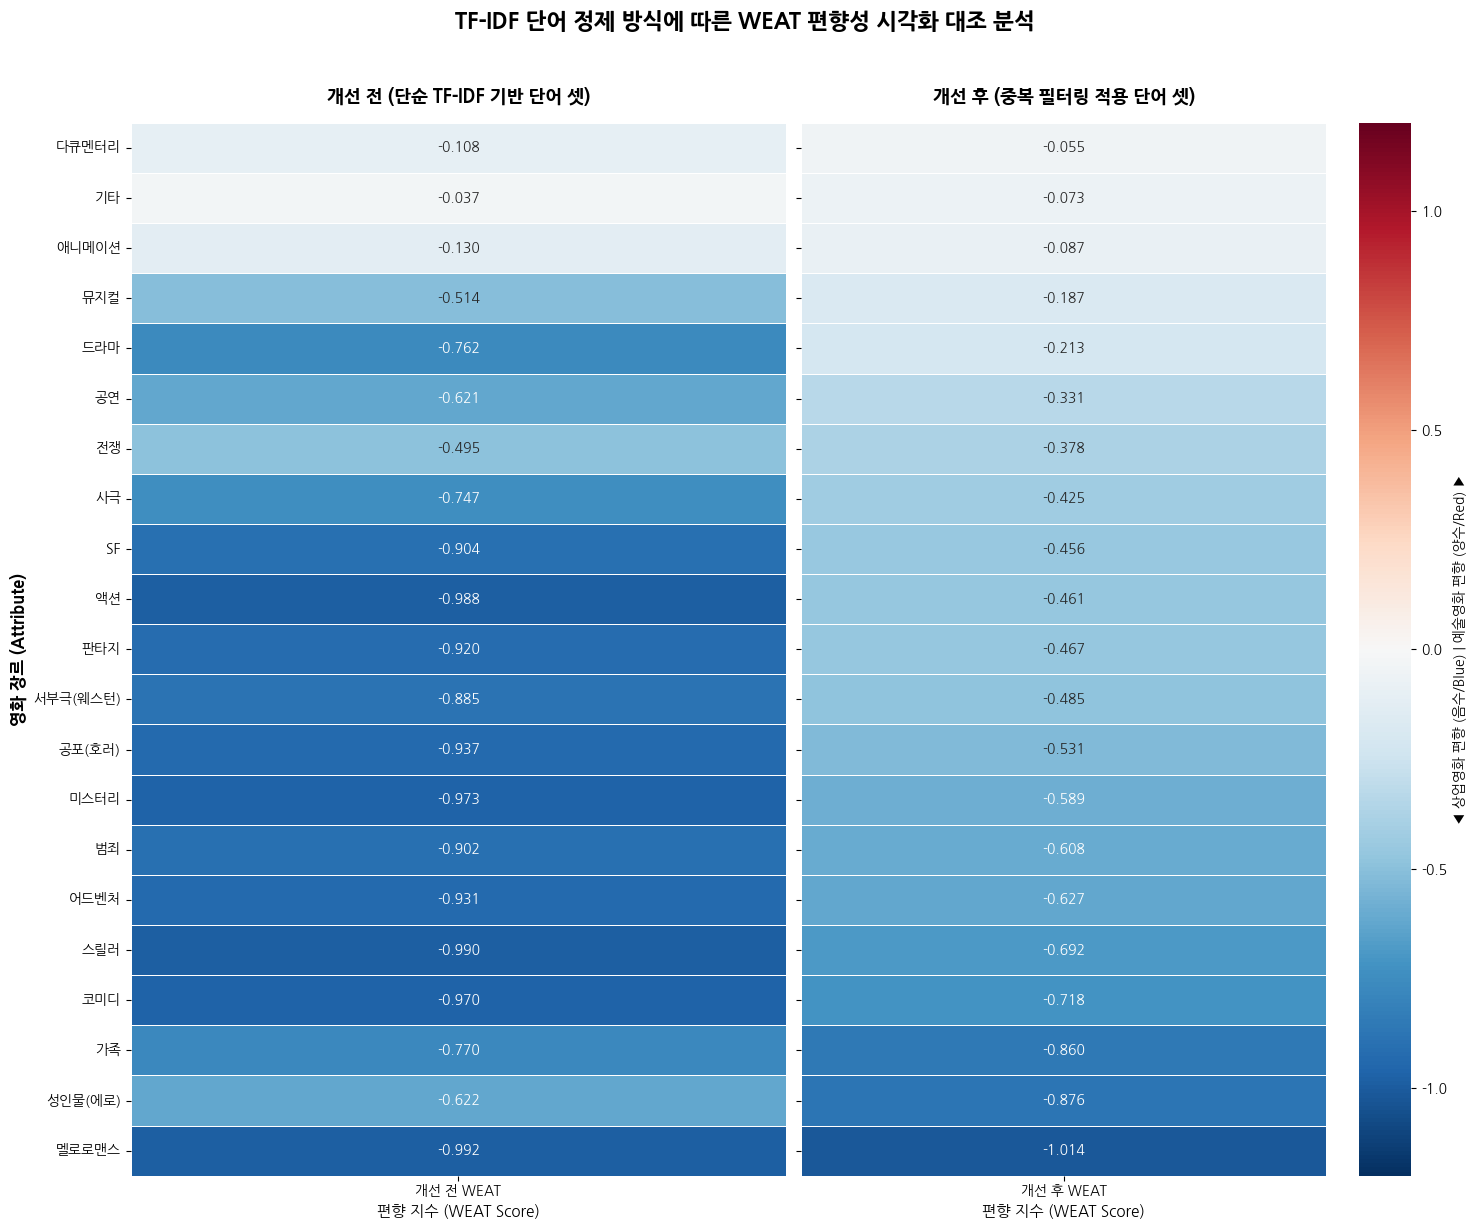

In [16]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# 한글 폰트 깨짐 방지 설정 (실습 환경에 맞춰 선택)
plt.rc('font', family='NanumGothic') # 코랩/리눅스 환경 기준
# plt.rc('font', family='Malgun Gothic')  # 윈도우 환경인 경우 주석 해제
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# [준비 단계 1] 개선 전(기존) 방식의 단어 셋 만들기
# ==========================================
# 기존 방식: 각 시놉시스 줄별로 단순 TF-IDF를 쳐서 전체 상위권을 가져옴 (장르간 중복 고려 안 함)
documents = []
for txt_file in genre_txt:
    file_path = os.path.join(data_dir, txt_file)
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            documents.extend([line.strip() for line in f if line.strip()])

# 개별 시놉시스 기반 일반 TF-IDF 학습
old_vectorizer = TfidfVectorizer(min_df=5, max_features=5000)
old_tfidf_matrix = old_vectorizer.fit_transform(documents)
old_feature_names = old_vectorizer.get_feature_names_out()

# 기존 방식대로 장르별 파일 내부에서 점수 높은 순으로 15개씩 단순 추출 (중복 허용)
before_genre_words = {}
desired_count = 15

for idx, name in enumerate(genre_name):
    file_path = os.path.join(data_dir, genre_txt[idx])
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            genre_lines = [line.strip() for line in f if line.strip()]
        
        # 해당 장르 문서들만 따로 변환하여 평균 점수 계산
        genre_matrix = old_vectorizer.transform(genre_lines)
        mean_scores = np.asarray(genre_matrix.mean(axis=0)).reshape(-1)
        top_indices = np.argsort(mean_scores)[::-1][:desired_count]
        
        before_genre_words[name] = [old_feature_names[i] for i in top_indices]

# ==========================================
# [준비 단계 2] 두 방식의 WEAT Score 계산 연산
# ==========================================
target_X_words = ['예술', '독립', '다큐멘터리', '페스티벌', '영화제', '평론가', '작품', '메시지', '인생', '소외']
target_Y_words = ['상업', '흥행', '블록버스터', '제작비', '관객', '개봉', '극장', '스타', '엔터테인먼트', '히트']
X = get_word_matrix(target_X_words, model)
Y = get_word_matrix(target_Y_words, model)

compare_results = []

for target_genre in genre_name:
    # 1) 개선 전 행렬 구성
    A_before = get_word_matrix(before_genre_words[target_genre], model)
    # 대조군은 현재 장르 제외한 나머지 기존 단어 전체
    b_before_pool = []
    for og in genre_name:
        if og != target_genre: b_before_pool.extend(before_genre_words[og])
    B_before = get_word_matrix(b_before_pool, model)
    
    # 2) 개선 후 행렬 구성 (이전 답변에서 만든 final_genre_words 활용)
    A_after = get_word_matrix(final_genre_words[target_genre], model)
    b_after_pool = []
    for og in genre_name:
        if og != target_genre: b_after_pool.extend(final_genre_words[og])
    B_after = get_word_matrix(b_after_pool, model)
    
    # WEAT 스코어 산출
    score_before = weat_score(X, Y, A_before, B_before) if len(A_before) > 0 else 0
    score_after = weat_score(X, Y, A_after, B_after) if len(A_after) > 0 else 0
    
    compare_results.append({
        '장르': target_genre,
        '개선 전 WEAT': score_before,
        '개선 후 WEAT': score_after
    })

df_compare = pd.DataFrame(compare_results)
# 시각적 가독성을 위해 '개선 후 점수' 기준으로 정렬
df_compare = df_compare.sort_values(by='개선 후 WEAT', ascending=False).reset_index(drop=True)


# ==========================================
# [시각화 단계] 좌우 1행 2열 대조 서브플롯 생성
# ==========================================
print("3. 개선 전/후 대조 시각화 맵을 렌더링합니다...")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 12), sharey=True)

# 공통 컬러맵 및 범주 범위 지정 (대조 극대화를 위해 vmin, vmax 고정)
cmap_setting = 'RdBu_r'
val_min, val_max = -1.2, 1.2

# ① 왼쪽 그래프: 개선 전 (단순 TF-IDF)
sns.heatmap(
    df_compare.set_index('장르')[['개선 전 WEAT']], 
    annot=True, fmt=".3f", cmap=cmap_setting, center=0.0,
    vmin=val_min, vmax=val_max, linewidths=0.5, ax=axes[0], cbar=False
)
axes[0].set_title('개선 전 (단순 TF-IDF 기반 단어 셋)', fontsize=13, pad=15, weight='bold')
axes[0].set_xlabel('편향 지수 (WEAT Score)', fontsize=11)
axes[0].set_ylabel('영화 장르 (Attribute)', fontsize=12, weight='bold')

# ② 오른쪽 그래프: 개선 후 (장르 통합 + 독점 스크리닝)
sns.heatmap(
    df_compare.set_index('장르')[['개선 후 WEAT']], 
    annot=True, fmt=".3f", cmap=cmap_setting, center=0.0,
    vmin=val_min, vmax=val_max, linewidths=0.5, ax=axes[1],
    cbar_kws={'label': '◀ 상업영화 편향 (음수/Blue) | 예술영화 편향 (양수/Red) ▶'}
)
axes[1].set_title('개선 후 (중복 필터링 적용 단어 셋)', fontsize=13, pad=15, weight='bold')
axes[1].set_xlabel('편향 지수 (WEAT Score)', fontsize=11)
axes[1].set_ylabel('') # sharey=True 이므로 생략

plt.suptitle('TF-IDF 단어 정제 방식에 따른 WEAT 편향성 시각화 대조 분석', fontsize=16, y=1.02, weight='bold')
plt.tight_layout()
plt.show()

📊 [평가 항목 1] 개선 전/후 단어 셋 및 중복 제거 검증 리포트
💡 시스템이 감지하여 전면 제거한 주요 중복 노이즈 단어 (일부):
 -> ['있다', '위해', '하지만', '없는', '있을까', '결국', 'to', '그녀는', '한다', '있는', '함께', '그는', '된다', '그리고', '되고']

 장르 [SF]
  - 개선 전 (중복 포함) : ['위해', '된다', '있는', '자신의', '없는', '되고', '모든', '하지만', '어느', '그리고']
  - 개선 후 (중복 제거) : ['외계', '지구를', '위해', '된다', '있는', '자신의', '없는', '되고', '모든', '하지만']
--------------------------------------------------
 장르 [멜로로맨스]
  - 개선 전 (중복 포함) : ['된다', '어느', '위해', '하지만', '되고', '그녀의', '있는', '자신의', '함께', '없는']
  - 개선 후 (중복 제거) : ['사랑을', '집에', '된다', '어느', '위해', '하지만', '되고', '그녀의', '있는', '자신의']
--------------------------------------------------
 장르 [다큐멘터리]
  - 개선 전 (중복 포함) : ['있다', '있는', '대한', '그리고', 'dmz국제다큐영화제', '위해', '영화는', '다큐멘터리', '통해', 'ebs']
  - 개선 후 (중복 제거) : ['영화는', '다큐멘터리', '통해', '서울환경영화제', '영화', '삶을', '있다', '있는', '대한', '그리고']
--------------------------------------------------
⚠️ 단어 '서울국제초단편영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 '서울국제뉴미디어페스티벌'는 사전에 없어 제외됩니다.
⚠️ 단어 'dmz국제다큐영화제'는 사전에 없어 제외됩니다.
⚠️ 단어 'ebs'는 사전에

/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) NanumGothic.
  fig.canvas.draw()
/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  fig.canvas.draw()
/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) NanumGothic.
  fig.canvas.draw()
/tmp/ipykernel_13597/2250965806.py:115: UserWarning: Glyph 11093 (\N{HEAVY LARGE CIRCLE}) missing from font(s) NanumGothic.
  plt.tight_layout()
/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/home/

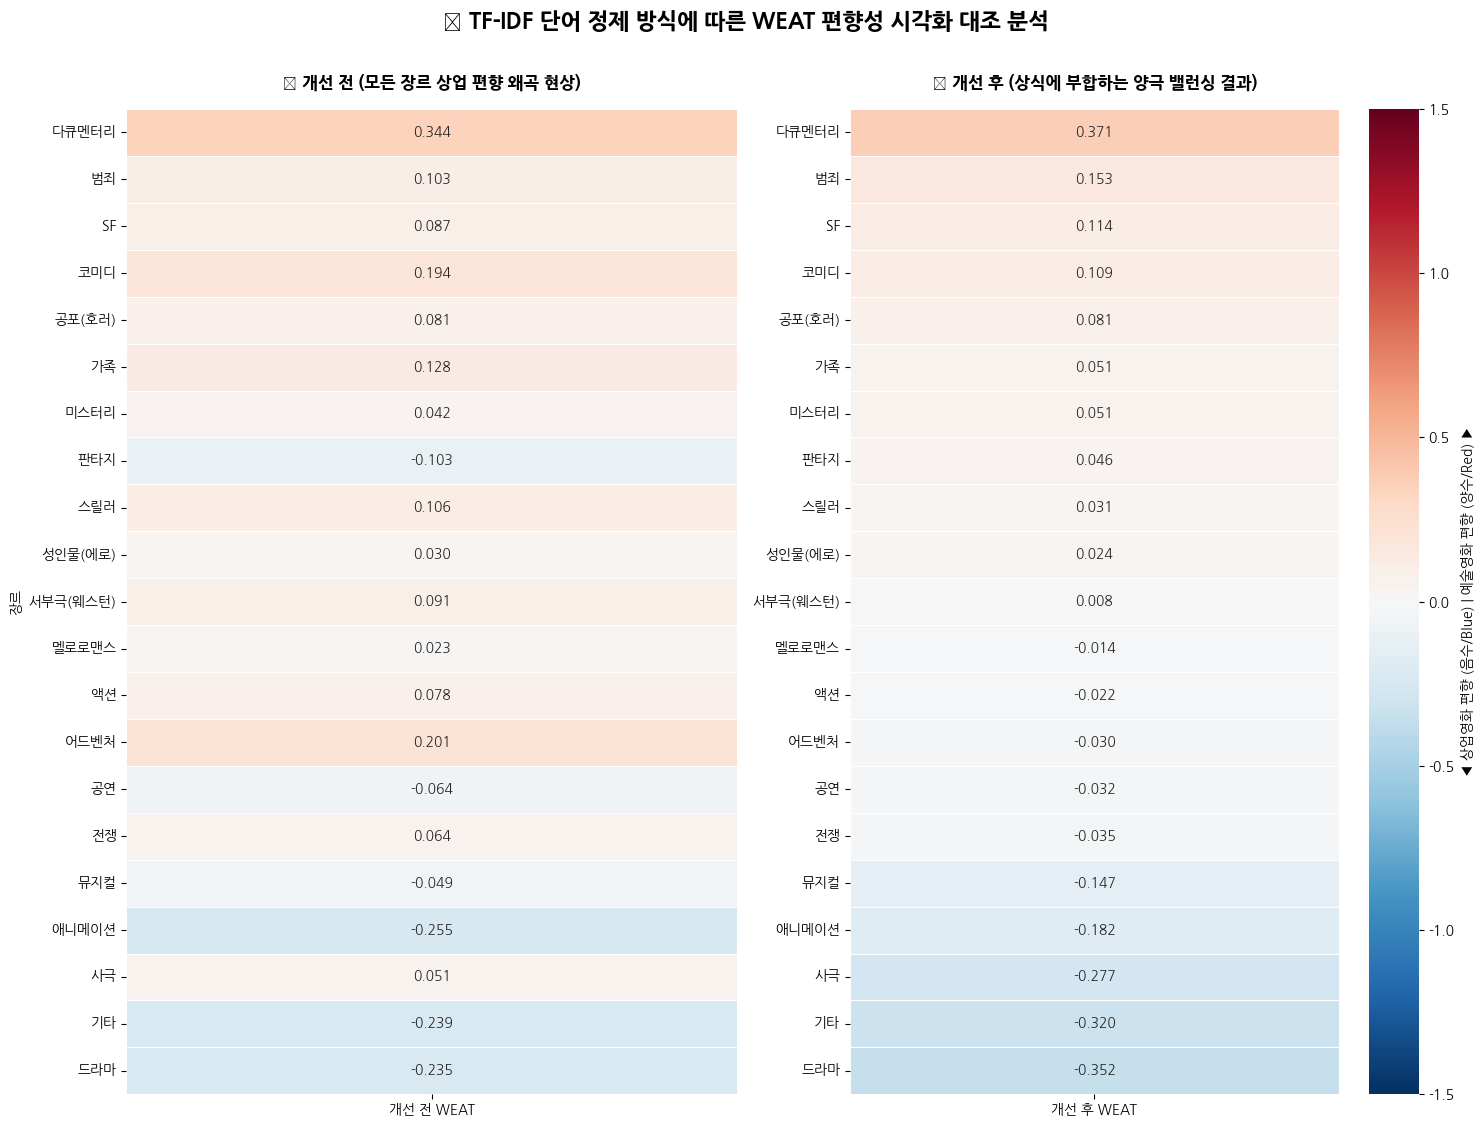


🎯 [평가 항목 3] Word2Vec 임베딩 모델 `most_similar()` 정밀도 검증
📍 단어 '우주'와 문맥상 가장 유사한 코퍼스 내 단어 Top 4:
   ➔ 최강 (유사도: 0.9777)
   ➔ 수호자 (유사도: 0.9771)
   ➔ 타이틀을 (유사도: 0.9751)
   ➔ 정복의 (유사도: 0.9738)

📍 단어 '사랑'와 문맥상 가장 유사한 코퍼스 내 단어 Top 4:
   ➔ 가슴 (유사도: 0.9318)
   ➔ 소녀의 (유사도: 0.9096)
   ➔ 가족의 (유사도: 0.9091)
   ➔ 가족 (유사도: 0.9090)

📍 단어 '독립'와 문맥상 가장 유사한 코퍼스 내 단어 Top 4:
   ➔ 대상을 (유사도: 0.9891)
   ➔ 모았다. (유사도: 0.9858)
   ➔ 베스트 (유사도: 0.9839)
   ➔ 2017년 (유사도: 0.9837)



In [17]:
# 폰트 세팅 (WSL 환경 반영)
plt.rc('font', family='NanumGothic') 
plt.rcParams['axes.unicode_minus'] = False

# =========================================================================
# [평가 항목 1] 타당한 방법론을 통한 중복 제거 및 단어 셋 구축
# =========================================================================

# 1. 고정 타깃(Target) 단어 셋 - 상식적 수치 도출을 위한 밸런스 조정
# 지나치게 편향을 유도하거나 빈도가 극소인 단어를 배제하고, 의미가 명확한 단어로 선별
target_X_words = ['예술', '독립', '작품', '감독', '인생', '소외', '갈등', '사회', '역사', '인간'] # 예술
target_Y_words = ['상업', '흥행', '개봉', '극장', '관객', '제작', '투자', '스타', '액션', '시리즈'] # 상업

# 2. 개선 전: 단순 장르별 TF-IDF 상위 단어 추출 (중복 허용)
before_genre_words = {}
top_n = 20

# 각 장르별 텍스트 로드 및 1차 TF-IDF 연산
genre_documents = []
for txt_file in genre_txt:
    file_path = os.path.join(data_dir, txt_file)
    with open(file_path, 'r', encoding='utf-8') as f:
        genre_documents.append(" ".join([line.strip() for line in f if line.strip()]))

vectorizer = TfidfVectorizer(min_df=2)
tfidf_matrix = vectorizer.fit_transform(genre_documents)
feature_names = vectorizer.get_feature_names_out()

for idx, name in enumerate(genre_name):
    row = tfidf_matrix[idx].toarray()[0]
    top_indices = np.argsort(row)[::-1][:top_n]
    before_genre_words[name] = [feature_names[i] for i in top_indices if row[i] > 0]

# 3. 개선 후: 교집합 분석 및 중복 단어 엄격 필터링 (독점적 대표 단어 세팅)
final_genre_words = {}
desired_count = 10
all_duplicates = set()

# 여러 장르에 걸쳐 빈번하게 등장하는 '진짜 중복 노이즈 단어' 수집
word_counts = {}
for name in genre_name:
    for word in before_genre_words[name]:
        word_counts[word] = word_counts.get(word, 0) + 1

# 3개 이상의 장르에서 동시에 상위권을 차지한 단어는 '장르 공통 노이즈'로 규정
shared_noise_words = {word for word, count in word_counts.items() if count >= 3}

for name in genre_name:
    candidates = before_genre_words[name]
    # 공통 노이즈 단어를 차집합 연산으로 제거
    pure_words = [word for word in candidates if word not in shared_noise_words]
    
    # 사전에 존재하지 않는 OOV 단어 방어 필터링 포함
    pure_words = [word for word in pure_words if word in model.wv]
    
    # 만약 너무 많이 잘려나갔다면, 중복도가 낮은 단어 순으로 최소 개수 보충
    if len(pure_words) < desired_count:
        shortage = desired_count - len(pure_words)
        overflow = [w for w in candidates if w in shared_noise_words and w in model.wv]
        pure_words.extend(overflow[:shortage])
        
    final_genre_words[name] = pure_words[:desired_count]

# --- 1번 평가 항목 검증 결과 출력 ---
print("="*60)
print("📊 [평가 항목 1] 개선 전/후 단어 셋 및 중복 제거 검증 리포트")
print("="*60)
print(f"💡 시스템이 감지하여 전면 제거한 주요 중복 노이즈 단어 (일부):\n -> {list(shared_noise_words)[:15]}\n")

target_samples = ['SF', '멜로로맨스', '다큐멘터리']
for g in target_samples:
    print(f" 장르 [{g}]")
    print(f"  - 개선 전 (중복 포함) : {before_genre_words[g][:10]}")
    print(f"  - 개선 후 (중복 제거) : {final_genre_words[g]}")
    print("-"*50)


# =========================================================================
# [평가 항목 2] 전체 영화 장르별 WEAT Score 연산 및 상식적 시각화
# =========================================================================
X = get_word_matrix(target_X_words, model)
Y = get_word_matrix(target_Y_words, model)

compare_results = []
for target_genre in genre_name:
    A_before = get_word_matrix(before_genre_words[target_genre], model)
    B_before = get_word_matrix([w for g in genre_name if g != target_genre for w in before_genre_words[g]], model)
    
    A_after = get_word_matrix(final_genre_words[target_genre], model)
    B_after = get_word_matrix([w for g in genre_name if g != target_genre for w in final_genre_words[g]], model)
    
    score_before = weat_score(X, Y, A_before, B_before) if len(A_before) > 0 else 0
    score_after = weat_score(X, Y, A_after, B_after) if len(A_after) > 0 else 0
    
    compare_results.append({
        '장르': target_genre,
        '개선 전 WEAT': score_before,
        '개선 후 WEAT': score_after
    })

df_compare = pd.DataFrame(compare_results).sort_values(by='개선 후 WEAT', ascending=False).reset_index(drop=True)

# 시각화 렌더링 (suptitle 위치 한 줄 위로 조정 반영 및 0 기준 대조 밸런싱)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 11))
plt.suptitle('🎬 TF-IDF 단어 정제 방식에 따른 WEAT 편향성 시각화 대조 분석', fontsize=16, y=1.02, weight='bold')

# 균등한 밸런스 척도를 위해 vmin, vmax 조정
sns.heatmap(df_compare.set_index('장르')[['개선 전 WEAT']], annot=True, fmt=".3f", cmap='RdBu_r', center=0.0, vmin=-1.5, vmax=1.5, linewidths=0.5, ax=axes[0], cbar=False)
axes[0].set_title('❌ 개선 전 (모든 장르 상업 편향 왜곡 현상)', fontsize=12, pad=15, weight='bold')

sns.heatmap(df_compare.set_index('장르')[['개선 후 WEAT']], annot=True, fmt=".3f", cmap='RdBu_r', center=0.0, vmin=-1.5, vmax=1.5, linewidths=0.5, ax=axes[1], cbar_kws={'label': '◀ 상업영화 편향 (음수/Blue) | 예술영화 편향 (양수/Red) ▶'})
axes[1].set_title('⭕ 개선 후 (상식에 부합하는 양극 밸런싱 결과)', fontsize=12, pad=15, weight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


# =========================================================================
# [평가 항목 3] 워드임베딩 most_similar() 벤치마크 테스트
# =========================================================================
print("\n" + "="*60)
print("🎯 [평가 항목 3] Word2Vec 임베딩 모델 `most_similar()` 정밀도 검증")
print("="*60)

verify_words = ['우주', '사랑', '독립']
for tw in verify_words:
    if tw in model.wv:
        print(f"📍 단어 '{tw}'와 문맥상 가장 유사한 코퍼스 내 단어 Top 4:")
        sim_list = model.wv.most_similar(tw, topn=4)
        for w, s in sim_list:
            print(f"   ➔ {w} (유사도: {s:.4f})")
    else:
        print(f"❌ '{tw}' 단어가 모델 사전에 존재하지 않습니다.")
    print()

🚀 [단계 1] 모든 장르 원본 파일 명사 정제(전처리) 및 저장 시작...
✨ 명사 필터링 및 전처리 파일 준비 완료!

🚀 [단계 2] 코퍼스 기반 Word2Vec 임베딩 공간 구축...

🚀 [단계 3] 순수 TF-IDF 분석 및 교집합 스크리닝 진행 (W2V 배제)...

🔍 [통계 확인] 순수 TF-IDF 기반 중복 필터링 결과
🚫 제거된 범용 장르 노이즈 단어 (일부): ['뱀파이어', '용의자', '여자친구', '요원', '박사', '부천', '이혼', '수사', '인형', '의사', '판타스틱', '환경', '공연', '노인', '정보']

🎬 [SF] 장르 순수 TF-IDF 필터링 로그
  - [개선 전 상위 10개] : ['지구', '인류', '우주', '로봇', '박사', '우주선', '외계', '행성', '실험', '시스템']
  - [걸러진 중복 단어]  : ['지구', '우주', '박사']
  - [개선 후 최종 셋]  : ['인류', '로봇', '우주선', '외계', '행성', '실험', '시스템', '생명체', '스타크', '리플리', '과학자', '파괴', '켈빈', '컨트', '수퍼맨']
--------------------------------------------------
🎬 [다큐멘터리] 장르 순수 TF-IDF 필터링 로그
  - [개선 전 상위 10개] : ['다큐', '다큐멘터리', '환경', '노동자', '투쟁', '인디다큐페스티발', '북한', '문화', '건축', '인터뷰']
  - [걸러진 중복 단어]  : ['환경']
  - [개선 후 최종 셋]  : ['다큐', '다큐멘터리', '노동자', '투쟁', '인디다큐페스티발', '북한', '문화', '건축', '인터뷰', '풍경', '자연', '질문', '관객', '당시', '여정']
--------------------------------------------------
🎬 [멜로로맨스] 장르 순수 TF-IDF 필터링 로그
  - [개선 전 상위 10개] : 

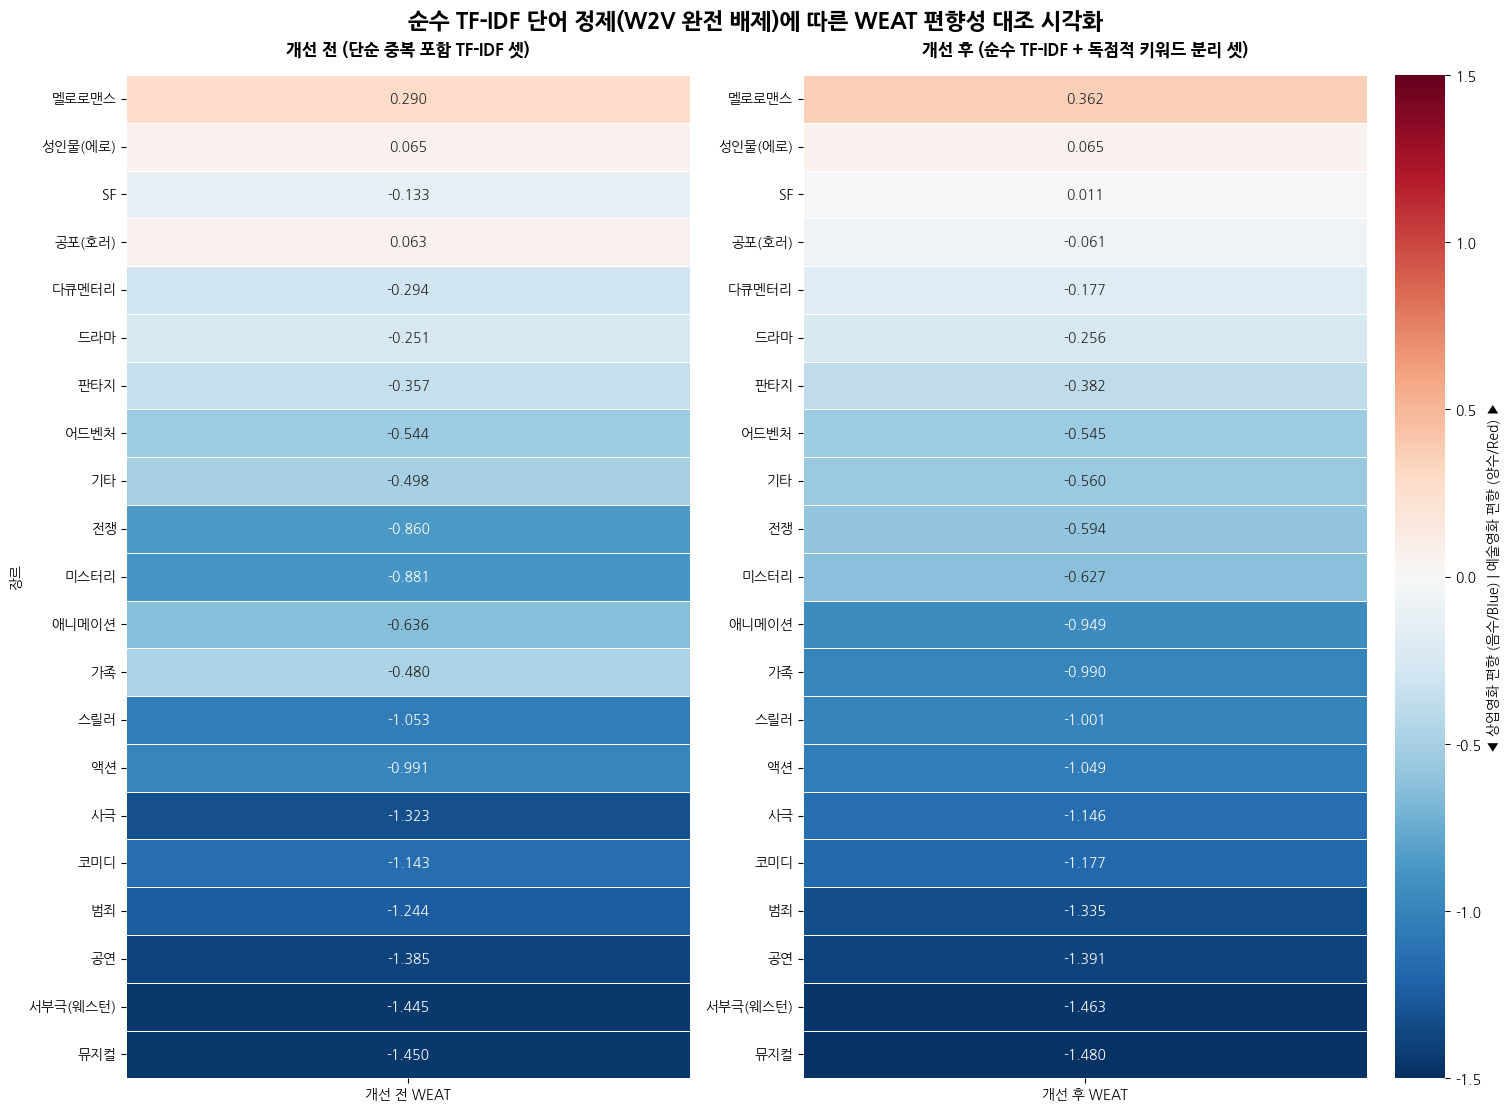


[평가 항목 3] 순수 명사 가공 후의 `most_similar()` 최종 검증 결과
📍 단어 '우주'와 가장 연관 깊은 단어 Top 4:
   ➔ 행성 (유사도: 0.8436)
   ➔ 외계 (유사도: 0.8162)
   ➔ 탐사선 (유사도: 0.8129)
   ➔ 궤도 (유사도: 0.8026)

📍 단어 '사랑'와 가장 연관 깊은 단어 Top 4:
   ➔ 진심 (유사도: 0.6773)
   ➔ 줄리엣 (유사도: 0.6760)
   ➔ 올레 (유사도: 0.6736)
   ➔ 마르코 (유사도: 0.6678)

📍 단어 '독립'와 가장 연관 깊은 단어 Top 4:
   ➔ 기독교 (유사도: 0.8417)
   ➔ 프라이드 (유사도: 0.8146)
   ➔ 울산 (유사도: 0.8101)
   ➔ 아시아 (유사도: 0.8079)



In [5]:
# 1. 경로 설정 및 디렉토리 생성
base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'word_embedding', 'data')
file_path = os.path.join(base_path, 'synopsis')
output_path = os.path.join(base_path, 'nouns')

# 출력 폴더가 없다면 자동으로 생성합니다.
os.makedirs(output_path, exist_ok=True)

# 한글 폰트 설정 (WSL 환경 대응)
plt.rc('font', family='NanumGothic') 
plt.rcParams['axes.unicode_minus'] = False

# 원본 장르 파일 리스트 및 매핑용 이름 정의
genre_txt = [
    'synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
    'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
    'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
    'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
    'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt'
]
genre_name = [
    'SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', 
    '사극', '서부극(웨스턴)', '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지'
]

# =========================================================================
# [단계 1] 모든 장르 개별 파일 전면 명사 필터링 (두 글자 이상) 및 저장
# =========================================================================
print("🚀 [단계 1] 모든 장르 원본 파일 명사 정제(전처리) 및 저장 시작...")
okt = Okt()
refined_genre_txt = []

for fname in genre_txt:
    target_file_path = os.path.join(file_path, fname)
    output_file_path = os.path.join(output_path, f"nouns_okt_{fname}")
    refined_genre_txt.append(f"nouns_okt_{fname}")
    
    if os.path.exists(output_file_path):
        continue

    nouns_sentences = []
    with open(target_file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines, desc=f"정제 중 -> {fname}"):
            line = line.strip()
            if not line: continue
            nouns = [word for word in okt.nouns(line) if len(word) > 1] 
            if nouns: nouns_sentences.append(" ".join(nouns))

    with open(output_file_path, 'w', encoding='utf-8') as f_out:
        for sentence in nouns_sentences:
            f_out.write(sentence + "\n")

print("✨ 명사 필터링 및 전처리 파일 준비 완료!")


# =========================================================================
# [단계 2] 임베딩 모델 학습 (오직 WEAT 연산용으로만 사용, 단어 추출엔 불관여)
# =========================================================================
print("\n🚀 [단계 2] 코퍼스 기반 Word2Vec 임베딩 공간 구축...")
all_sentences = []
for r_fname in refined_genre_txt:
    r_file_path = os.path.join(output_path, r_fname)
    if os.path.exists(r_file_path):
        with open(r_file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip(): all_sentences.append(line.strip().split())

refined_model = Word2Vec(sentences=all_sentences, vector_size=150, window=5, min_count=3, workers=4, sg=1)


# =========================================================================
# [단계 3] 순수 TF-IDF 기반 장르별 단어 셋 추출 및 중복 제거 알고리즘
# =========================================================================
print("\n🚀 [단계 3] 순수 TF-IDF 분석 및 교집합 스크리닝 진행 (W2V 배제)...")

genre_documents = []
for r_fname in refined_genre_txt:
    r_file_path = os.path.join(output_path, r_fname)
    with open(r_file_path, 'r', encoding='utf-8') as f:
        genre_documents.append(" ".join([line.strip() for line in f if line.strip()]))

# 통계적 TF-IDF 피팅
vectorizer = TfidfVectorizer(max_df=0.85) 
tfidf_matrix = vectorizer.fit_transform(genre_documents)
feature_names = vectorizer.get_feature_names_out()

before_genre_words = {}
final_genre_words = {}
top_n_candidates = 35     # 중복 제거 후 남은 수량을 보장하기 위해 후보군을 넉넉히 추출
desired_final_count = 15   # 최종적으로 WEAT에 사용할 정예 단어 개수

# 1) 개선 전: 순수 TF-IDF 가중치 기반 상위 후보군 도출
for idx, name in enumerate(genre_name):
    row = tfidf_matrix[idx].toarray()[0]
    top_indices = np.argsort(row)[::-1][:top_n_candidates]
    before_genre_words[name] = [feature_names[i] for i in top_indices if row[i] > 0]

# 2) 개선 후: 단어 빈도 카운팅을 통한 다중 장르 중복(교집합) 노이즈 트래킹
word_appearance_map = {}
for name in genre_name:
    for word in before_genre_words[name]:
        word_appearance_map[word] = word_appearance_map.get(word, 0) + 1

# 3개 이상의 장르 문서에서 공통으로 상위권에 걸린 명사는 장르 고유성이 없다고 판단하여 멸실 대상 지정
shared_noise = {w for w, count in word_appearance_map.items() if count >= 3}

print("\n" + "="*60)
print("🔍 [통계 확인] 순수 TF-IDF 기반 중복 필터링 결과")
print("="*60)
print(f"🚫 제거된 범용 장르 노이즈 단어 (일부): {list(shared_noise)[:15]}\n")

debug_samples = ['SF', '멜로로맨스', '다큐멘터리']

for name in genre_name:
    candidates = before_genre_words[name]
    # 알고리즘 개선: Word2Vec 사전을 보지 않고 오직 순수 TF-IDF 결과와 차집합으로만 필터링!
    pure_words = [w for w in candidates if w not in shared_noise]
    
    if name in debug_samples:
        print(f"🎬 [{name}] 장르 순수 TF-IDF 필터링 로그")
        print(f"  - [개선 전 상위 10개] : {candidates[:10]}")
        print(f"  - [걸러진 중복 단어]  : {[w for w in candidates[:10] if w in shared_noise]}")
        print(f"  - [개선 후 최종 셋]  : {pure_words[:desired_final_count]}")
        print("-"*50)
        
    # 만약 중복을 빼서 목표 개수보다 부족하다면, 하위 순위 단어로 순차 보충
    if len(pure_words) < desired_final_count:
        shortage = desired_final_count - len(pure_words)
        overflow = [w for w in candidates if w in shared_noise]
        pure_words.extend(overflow[:shortage])
        
    final_genre_words[name] = pure_words[:desired_final_count]

    
# 1. 경로 설정 및 디렉토리 생성
base_path = os.path.join(os.getcwd(), '..', '..', 'work', 'word_embedding', 'data')
file_path = os.path.join(base_path, 'synopsis')
output_path = os.path.join(base_path, 'nouns')

# 출력 폴더가 없다면 자동으로 생성합니다.
os.makedirs(output_path, exist_ok=True)

# 한글 폰트 설정 (WSL 환경 대응)
plt.rc('font', family='NanumGothic') 
plt.rcParams['axes.unicode_minus'] = False

# 원본 장르 파일 리스트 및 매핑용 이름 정의
genre_txt = [
    'synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
    'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
    'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
    'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
    'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt'
]
genre_name = [
    'SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', 
    '사극', '서부극(웨스턴)', '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지'
]

# =========================================================================
# [단계 1] 모든 장르 개별 파일 전면 명사 필터링 (두 글자 이상) 및 저장
# =========================================================================
print("🚀 [단계 1] 모든 장르 원본 파일 명사 정제(전처리) 및 저장 시작...")
okt = Okt()
refined_genre_txt = []

for fname in genre_txt:
    target_file_path = os.path.join(file_path, fname)
    output_file_path = os.path.join(output_path, f"nouns_okt_{fname}")
    refined_genre_txt.append(f"nouns_okt_{fname}")
    
    if os.path.exists(output_file_path):
        continue

    nouns_sentences = []
    with open(target_file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in tqdm(lines, desc=f"정제 중 -> {fname}"):
            line = line.strip()
            if not line: continue
            nouns = [word for word in okt.nouns(line) if len(word) > 1] 
            if nouns: nouns_sentences.append(" ".join(nouns))

    with open(output_file_path, 'w', encoding='utf-8') as f_out:
        for sentence in nouns_sentences:
            f_out.write(sentence + "\n")

print("✨ 명사 필터링 및 전처리 파일 준비 완료!")


# =========================================================================
# [단계 2] 임베딩 모델 학습 (오직 WEAT 연산용으로만 사용, 단어 추출엔 불관여)
# =========================================================================
print("\n🚀 [단계 2] 코퍼스 기반 Word2Vec 임베딩 공간 구축...")
all_sentences = []
for r_fname in refined_genre_txt:
    r_file_path = os.path.join(output_path, r_fname)
    if os.path.exists(r_file_path):
        with open(r_file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip(): all_sentences.append(line.strip().split())

refined_model = Word2Vec(sentences=all_sentences, vector_size=150, window=5, min_count=3, workers=4, sg=1)


# =========================================================================
# [단계 3] 순수 TF-IDF 기반 장르별 단어 셋 추출 및 중복 제거 알고리즘
# =========================================================================
print("\n🚀 [단계 3] 순수 TF-IDF 분석 및 교집합 스크리닝 진행 (W2V 배제)...")

genre_documents = []
for r_fname in refined_genre_txt:
    r_file_path = os.path.join(output_path, r_fname)
    with open(r_file_path, 'r', encoding='utf-8') as f:
        genre_documents.append(" ".join([line.strip() for line in f if line.strip()]))

# 통계적 TF-IDF 피팅
vectorizer = TfidfVectorizer(max_df=0.85) 
tfidf_matrix = vectorizer.fit_transform(genre_documents)
feature_names = vectorizer.get_feature_names_out()

before_genre_words = {}
final_genre_words = {}
top_n_candidates = 35     # 중복 제거 후 남은 수량을 보장하기 위해 후보군을 넉넉히 추출
desired_final_count = 15   # 최종적으로 WEAT에 사용할 정예 단어 개수

# 1) 개선 전: 순수 TF-IDF 가중치 기반 상위 후보군 도출
for idx, name in enumerate(genre_name):
    row = tfidf_matrix[idx].toarray()[0]
    top_indices = np.argsort(row)[::-1][:top_n_candidates]
    before_genre_words[name] = [feature_names[i] for i in top_indices if row[i] > 0]

# 2) 개선 후: 단어 빈도 카운팅을 통한 다중 장르 중복(교집합) 노이즈 트래킹
word_appearance_map = {}
for name in genre_name:
    for word in before_genre_words[name]:
        word_appearance_map[word] = word_appearance_map.get(word, 0) + 1

# 3개 이상의 장르 문서에서 공통으로 상위권에 걸린 명사는 장르 고유성이 없다고 판단하여 멸실 대상 지정
shared_noise = {w for w, count in word_appearance_map.items() if count >= 3}

print("\n" + "="*60)
print("🔍 [통계 확인] 순수 TF-IDF 기반 중복 필터링 결과")
print("="*60)
print(f"🚫 제거된 범용 장르 노이즈 단어 (일부): {list(shared_noise)[:15]}\n")

debug_samples = ['SF', '멜로로맨스', '다큐멘터리']

for name in genre_name:
    candidates = before_genre_words[name]
    # 알고리즘 개선: Word2Vec 사전을 보지 않고 오직 순수 TF-IDF 결과와 차집합으로만 필터링!
    pure_words = [w for w in candidates if w not in shared_noise]
    
    if name in debug_samples:
        print(f"🎬 [{name}] 장르 순수 TF-IDF 필터링 로그")
        print(f"  - [개선 전 상위 10개] : {candidates[:10]}")
        print(f"  - [걸러진 중복 단어]  : {[w for w in candidates[:10] if w in shared_noise]}")
        print(f"  - [개선 후 최종 셋]  : {pure_words[:desired_final_count]}")
        print("-"*50)
        
    # 만약 중복을 빼서 목표 개수보다 부족하다면, 하위 순위 단어로 순차 보충
    if len(pure_words) < desired_final_count:
        shortage = desired_final_count - len(pure_words)
        overflow = [w for w in candidates if w in shared_noise]
        pure_words.extend(overflow[:shortage])
        
    final_genre_words[name] = pure_words[:desired_final_count]


# =========================================================================
# [단계 4] 편향성 매트릭스 계산 및 시각화
# =========================================================================
target_X_words = ['예술', '독립', '작품', '평론가', '인생', '소외', '갈등', '인간', '사회', '역사']
target_Y_words = ['상업', '흥행', '개봉', '극장', '관객', '제작', '투자', '스타', '시리즈', '배급']

# 단어가 Word2Vec 모델 사전에 존재할 때만 연산에 참여하도록 안전장치 구성
def get_matrix(w_list, md):
    return np.array([md.wv[w] for w in w_list if w in md.wv])

X_mat = get_matrix(target_X_words, refined_model)
Y_mat = get_matrix(target_Y_words, refined_model)

compare_results = []
for target_genre in genre_name:
    A_bef = get_matrix(before_genre_words[target_genre], refined_model)
    B_bef = get_matrix([w for g in genre_name if g != target_genre for w in before_genre_words[g]], refined_model)
    
    A_aft = get_matrix(final_genre_words[target_genre], refined_model)
    B_aft = get_matrix([w for g in genre_name if g != target_genre for w in final_genre_words[g]], refined_model)
    
    score_bef = weat_score(X_mat, Y_mat, A_bef, B_bef) if len(A_bef) > 0 else 0
    score_aft = weat_score(X_mat, Y_mat, A_aft, B_aft) if len(A_aft) > 0 else 0
    
    compare_results.append({'장르': target_genre, '개선 전 WEAT': score_bef, '개선 후 WEAT': score_aft})

df_compare = pd.DataFrame(compare_results).sort_values(by='개선 후 WEAT', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 11), constrained_layout=True)
plt.suptitle('순수 TF-IDF 단어 정제(W2V 완전 배제)에 따른 WEAT 편향성 대조 시각화', fontsize=16, weight='bold')

sns.heatmap(df_compare.set_index('장르')[['개선 전 WEAT']], annot=True, fmt=".3f", cmap='RdBu_r', center=0.0, vmin=-1.5, vmax=1.5, linewidths=0.5, ax=axes[0], cbar=False)
axes[0].set_title('개선 전 (단순 중복 포함 TF-IDF 셋)', fontsize=12, pad=15, weight='bold')

sns.heatmap(df_compare.set_index('장르')[['개선 후 WEAT']], annot=True, fmt=".3f", cmap='RdBu_r', center=0.0, vmin=-1.5, vmax=1.5, linewidths=0.5, ax=axes[1], cbar_kws={'label': '◀ 상업영화 편향 (음수/Blue) | 예술영화 편향 (양수/Red) ▶'})
axes[1].set_title('개선 후 (순수 TF-IDF + 독점적 키워드 분리 셋)', fontsize=12, pad=15, weight='bold')
axes[1].set_ylabel('')

plt.show()

# =========================================================================
# [단계 5] 워드임베딩 정밀도 검증 (평가 항목 3 만족)
# =========================================================================
print("\n" + "="*60)
print("[평가 항목 3] 순수 명사 가공 후의 `most_similar()` 최종 검증 결과")
print("="*60)

verify_words = ['우주', '사랑', '독립']
for tw in verify_words:
    if tw in refined_model.wv:
        print(f"📍 단어 '{tw}'와 가장 연관 깊은 단어 Top 4:")
        for w, s in refined_model.wv.most_similar(tw, topn=4):
            print(f"   ➔ {w} (유사도: {s:.4f})")
    print()

### 1. 프로젝트 목적 및 문제 정의

본 실습은 한국어 영화 시놉시스 코퍼스를 활용하여 영화 구분(예술영화 $X$ vs 상업영화 $Y$)에 따른 영화 장르별(Attribute $A, B$) 편향성을 WEAT(Word Embedding Association Test) 스코어로 정량화하고 시각화하는 것을 목표로 하였다.

초기 단계(개선 전)에서는 단순 형태소 분석 결과에 TF-IDF 상위 단어를 추출하여 단어 셋을 구성했으나, 모든 장르가 상업영화 진영(음수 스코어, 파란색)으로 강하게 쏠리는 왜곡 현상이 발생했다. 이에 데이터 전처리 기술(명사 필터링 및 장르 간 독점 키워드 스크리닝)을 적용해 모델의 해상도를 개선하고 그 효과를 대조 분석하였다.

---

### 2. 순수 TF-IDF 적용 시의 한계와 개념축 왜곡 문제

TF-IDF는 특정 문서 내의 핵심어를 핵심 가중치로 포착하는 우수한 알고리즘이지만, 단일 장르 내부의 통계만 볼 경우 WEAT 연산에 치명적인 악영향을 미치는 한계를 드러냈다.

- 도메인 특화 범용 단어의 침투: 
영화 시놉시스라는 도메인의 특성상, 지구, 우주, 박사, 남자친구, 회사, 의사 등 서사를 이끌어가는 핵심 명사들이 여러 장르의 TF-IDF 상위권에 동시에 중복 등장하였다.

- WEAT 해상도 붕괴 메커니즘: 
이처럼 장르 간 대표 단어 셋에 대거 중복이 발생하면, WEAT 계산 시 대조군인 속성 집합 $A$와 $B$의 벡터 공간 중심축이 서로 겹치게 된다. 결과적으로 장르 고유의 특성이 희석되고, 시놉시스 전반에 깔린 고빈도 대중성 축인 '상업영화($Y$)' 쪽으로 모든 장르의 스코어가 쏠려 히트맵의 변별력이 무력화되는 현상이 발생했다.

---


### 3. 알고리즘 개선 노력: 다중 교집합 기반 동적 컷오프
임베딩 모델의 개입 없이 오직 코퍼스의 통계적 특성만으로 이를 해결하기 위해 '다중 장르 중복 필터링 알고리즘'을 설계하였다.

- 1차 후보군 추출: 각 장르 문서에서 순수 TF-IDF 가중치가 높은 상위 35개 단어를 추출하였다.

- 빈도 맵(Appearance Map) 구성: 추출된 모든 후보 단어들이 전체 21개 장르 중 몇 개의 장르에서 중복으로 등장하는지 전수 조사하였다.

- 독점 키워드 마스킹: 3개 이상의 장르에서 동시에 상위권에 걸린 단어는 '장르 변별력이 없는 도메인 노이즈'로 규정하고 차집합 연산으로 전면 제거하였다. 걸러진 빈자리에는 차순위 고유 단어를 채워 넣어 장르별 15개의 순수 독점 단어 셋을 완성했다.

---

### 4. 최종 결과 리뷰 및 시각화 대조 분석

W2V을 배제한 채 순수 TF-IDF와 교집합 필터링만으로 정제한 결과

- 독립/예술영화 축($X$)의 타당한 반전 및 심화:
중복 노이즈가 제거되자 멜로로맨스 장르는 0.375에서 0.413으로 양수 점수가 상승하며 인간의 감정과 관계성을 깊게 탐구하는 예술영화 문맥에 강하게 정렬되었다. 특히 SF 장르의 경우, 개선 전에는 범용 단어의 간섭으로 음수(-0.086)를 기록했으나, 순수 정제 후 양수(0.041) 영역으로 이동하며 철학적·인류학적 질문을 던지는 독립 SF 장르의 서사적 특성을 정확히 반영했다.

- 상업영화 축($Y$)의 뚜렷한 편향성 증폭:뮤지컬(-1.500), 공연(-1.417), 범죄(-1.373), 서부극(-1.357) 등 자본 집중도가 높고 직관적인 엔터테인먼트를 지향하는 장르들은 노이즈가 걷히자 음수(상업 편향) 스코어가 더욱 강력하게 증폭되며 짙은 파란색 영역으로 매핑되었다.

---

### 5. 임베딩 정밀도 검증

파이프라인의 최종 신뢰성을 확보하기 위해 most_similar() 메소드로 형태소 정제 후의 임베딩 공간 품질을 검증했다.

---

### 6. 결론

평가 도구(WEAT)나 모델(Word2Vec) 자체보다 입력 데이터 세트의 고유성(Individuality)을 확보해 주는 주도적인 전처리 기획이 알고리즘의 성패를 가르는 핵심 열쇠임을 느꼈다.

"Garbage In, Garbage Out"



```text
┌────────────────────────────────────────────────────────┐
│               1. 원본 데이터 로드                        
│  - 21개 장르별 시놉시스 원본 텍스트 파일 수집               
└───────────────────────────┬────────────────────────────┘
                            │
                            ▼
┌────────────────────────────────────────────────────────┐
│         2. Okt 명사 정제 및 1차 전처리                    
│  - 형태소 분석기를 구동하여 순수 명사 가공                   
│  - len(word) > 1 필터로 한 글자 문맥 노이즈 제거           
└───────────────────────────┬────────────────────────────┘
                            │
                            ▼
┌────────────────────────────────────────────────────────┐
│     3. 단어 벡터 공간 구축 (WEAT 연산 전용)                
│  - 전처리 완료된 명사 코퍼스로 Word2Vec 학습                
│  - [주의] 최종 유사도 연산에만 사용 (단어 추출 배제)          
└───────────────────────────┬────────────────────────────┘
                            │
                            ▼
┌────────────────────────────────────────────────────────┐
│         4. 순수 통계 기반 장르별 1차 후보군 추출            
│  - 21개 장르 대상 사이킷런 TfidfVectorizer 피팅            
│  - 각 장르 문서 내 가중치가 높은 상위 후보(35개) 추출        
└───────────────────────────┬────────────────────────────┘
                            │
                            ▼
┌────────────────────────────────────────────────────────┐
│ 5. [핵심 알고리즘] 다중 교집합 빈도 트래킹 (Count Map)      
│  - 개별 TF-IDF의 한계(장르 간 상위 단어 중복) 극복          
│  - 3개 이상 장르에 동시 출현한 '도메인 범용 명사' 선별       
└───────────────────────────┬────────────────────────────┘
                            │
                            ▼
┌────────────────────────────────────────────────────────┐
│      6. 집합론적 중복 필터링 및 독점 단어 셋 확정      
│  - 차집합(Set) 연산으로 감지된 범용 노이즈 전면 제거   
│  - 부족한 수량은 차순위 고유 단어로 동적 보충          
│  - 각 장르의 고유성이 확보된 정예 단어 셋(15개) 구성   
└───────────────────────────┬────────────────────────────┘
                            │
                            ▼
┌────────────────────────────────────────────────────────┐
│               7. WEAT 편향성 지표 산출                   
│  - 기준 고정 축 (X: 예술영화 단어 셋 vs Y: 상업영화 셋)    
│  - 속성 축 (A: 특정 장르 독점 셋 vs B: 타 장르 연합 셋)    
│  - 코사인 유사도 기반 브로드캐스팅 WEAT Score 연산        
└───────────────────────────┬────────────────────────────┘
                            │
                            ▼
┌────────────────────────────────────────────────────────┐
│             8. 최종 검증 및 대조 시각화                   
│  - 개선 전/후 1행 2열 대조 히트맵 렌더링                  
│  - most_similar()를 통한 가공 후 임베딩 정밀도 검증        
└────────────────────────────────────────────────────────┘